## This script makes supplemental Fig. S1, about the distribution of weather stations
#### Noel Siegert, 2/25/26

In [1]:
# kernel: pangeo23
# see also: 'qualspaper_supfig_3_3.ipynb'

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'FigS1_submissionFeb26.ipynb'

In [5]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

gdf

,STAID,STANAME,LAT,LON,ELEV,START,END,DIST2COAST,PCTREPORTING,max_pctmissing_month,geometry
0,010014-99999,SORSTOKKEN,59.792,5.341,48.8,1986-11-20,2024-02-02,1.377415,82.28,26.021505,POINT (5.34100 59.79200)
1,011020-99999,SKLINNA FYR,65.200,11.000,16.0,1975-02-28,2024-02-02,23.468849,92.73,16.646989,POINT (11.00000 65.20000)
2,011120-99999,BRONNOY,65.461,12.218,7.6,1973-01-01,2024-02-02,0.976040,96.37,12.514758,POINT (12.21800 65.46100)
3,011160-99999,STOKKA,65.950,12.467,17.1,1973-04-01,2024-02-02,1.240810,95.79,15.702479,POINT (12.46700 65.95000)
4,011210-99999,SOLVAER III,66.367,12.617,10.0,1973-01-01,2024-02-02,10.035263,87.32,17.222222,POINT (12.61700 66.36700)
...,...,...,...,...,...,...,...,...,...,...,...
1469,987520-99999,BUTUAN,8.950,125.483,46.0,1981-01-01,2024-02-02,4.531335,96.62,6.666667,POINT (125.48300 8.95000)
1470,987530-99999,FRANCISCO BANGOY INTL,7.126,125.646,29.3,1974-06-01,2024-02-02,1.183564,99.53,3.111111,POINT (125.64600 7.12600)
1471,987550-99999,HINATUAN,8.367,126.333,3.0,1949-10-01,2023-12-07,1.553108,96.70,6.021505,POINT (126.33300 8.36700)
1472,988360-99999,ZAMBOANGA INTL,6.922,122.060,10.1,1945-03-12,2024-02-02,2.489244,99.64,2.333333,POINT (122.06000 6.92200)


In [6]:
# make some binned lat things for the supplemental fig. 
pctreport_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['PCTREPORTING'].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:52: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


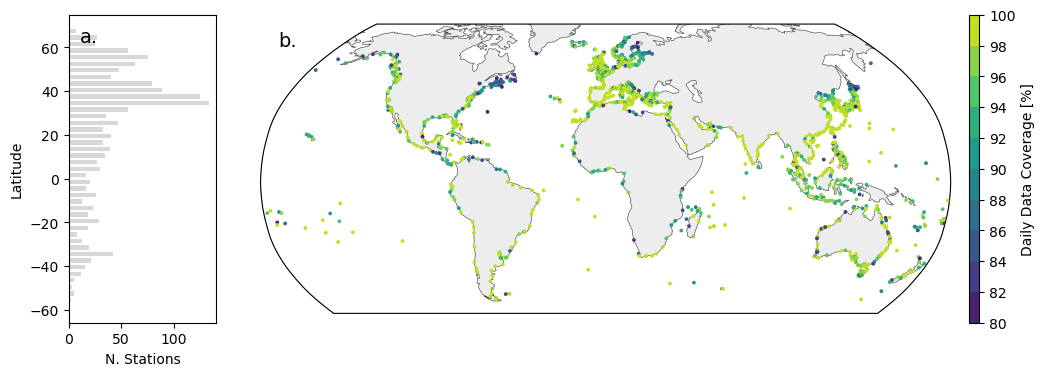

a: Num station obs. b. percent of daily coverage for every station.


In [7]:
# set cmap -- fiddle with this some more in the future
vmin = 80
vmax = 100
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('viridis')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
#cmap.set_over(cols[-1])
#cmap.set_under(bluecolors[-4])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)



# setup axes
nrows = 1
ncols = 2
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 5]) 
gs.update(wspace=0.1, hspace=0.1)

## Plot data
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())


# ax 0 - number of obs. by latitude
ax0.barh(bin_midpoints, bin_nobs, height=2, color='grey', lw=2, alpha=0.3, zorder=0)
ax0.set(ylabel='Latitude', xlabel='N. Stations')


# ax 1 - pct reporting characteristics
gdf.plot(column='PCTREPORTING', ax=ax1, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
ax1.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
ax1.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 



sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, 
                    ax=ax1, 
                    orientation="vertical",
                    label="Daily Data Coverage [%]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.04, 
                    ticks=bounds,
                    aspect=30)


ax0.text(s='a.', x=0.075, y=0.91, transform=ax0.transAxes, ha='left', fontsize=14)
ax1.text(s='b.', x=0.025, y=0.925, transform=ax1.transAxes, ha='left', fontsize=14)


# # timestamp + script
# now = datetime.now() # get datetime
# fig.text(0.85, 0.01, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='small', ha='right') # text
# fig.text(0.85, 0.035, script, ha='right', fontsize='small')


plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/FigS1_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()

print('a: Num station obs. b. percent of daily coverage for every station.')